# State of Data — EDA: Gênero (2021–2024)
Análise exploratória focada na dimensão de gênero ao longo dos quatro anos de pesquisa.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

# ── Estilo global ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
})

# Paleta de gênero — usada em todos os gráficos
CORES = {'Masculino': '#517493', 'Feminino': '#64313E'}
ANOS  = ['2021', '2022', '2023', '2024']

# ── Carrega o DataFrame já tratado ────────────────────────────────────────
df = pd.read_excel('df_full.xlsx')

# Garante que as categóricas ordenadas estejam corretas após leitura do Excel
FAIXA_SALARIAL_ORDEM = [
    'R$1k-2k','R$2k-3k','R$3k-4k','R$4k-6k','R$6k-8k',
    'R$8k-12k','R$12k-16k','R$16k-20k','R$20k-25k',
    'R$25k-30k','R$30k-40k','R$40k+',
]
NIVEL_ENSINO_ORDEM = [
    'Não tenho graduação formal','Estudante de Graduação',
    'Graduação/Bacharelado','Especialização Lato Sensu','Mestrado','Doutorado ou Phd',
]
NIVEL_SENIORIDADE_ORDEM = ['Júnior','Pleno','Sênior','Gestor']

df['faixa_salarial'] = pd.Categorical(df['faixa_salarial'], categories=FAIXA_SALARIAL_ORDEM, ordered=True)
df['nivel_ensino']   = pd.Categorical(df['nivel_ensino'],   categories=NIVEL_ENSINO_ORDEM,   ordered=True)
df['nivel']          = pd.Categorical(df['nivel'],          categories=NIVEL_SENIORIDADE_ORDEM, ordered=True)
df['ano_pesquisa']   = df['ano_pesquisa'].astype(str)

print(f'Linhas: {len(df):,} | Anos: {sorted(df["ano_pesquisa"].unique())}')
df.head(2)

Linhas: 17,295 | Anos: ['2021', '2022', '2023', '2024']


,ano_pesquisa,idade,faixa_idade,genero,estado,uf,regiao,regiao_origem,mudou_estado,nivel_ensino,area_formacao,situacao,setor,cargo,gestor,nivel,faixa_salarial,tempo_area_dados,tempo_area_ti,modalidade
0,2021,38.0,35-39,Masculino,Ceará (CE),CE,Nordeste,NaN,0.0,Especialização Lato Sensu,Química / Física,Empregado (CLT),Marketing,NaN,1.0,Gestor,R$4k-6k,Mais de 10 anos,Não tive experiência na área de TI/Engenharia ...,Modelo 100% presencial
1,2021,39.0,35-39,Masculino,Bahia (BA),BA,Nordeste,Sudeste,1.0,Especialização Lato Sensu,Economia / Administração / Finanças / Negócios,Empreendedor ou Empregado (CNPJ),Consultoria,NaN,1.0,Gestor,R$6k-8k,de 2 a 3 anos,Não tive experiência na área de TI/Engenharia ...,Modelo híbrido flexível (o funcionário tem lib...


## Funções auxiliares

In [2]:
def prop_por_grupo(df, col_grupo, col_genero='genero'):
    """
    Retorna proporção de cada gênero dentro de cada grupo (col_grupo),
    somando a 100 % por linha.
    """
    ct = df.groupby([col_grupo, col_genero], observed=True).size().unstack(fill_value=0)
    return ct.div(ct.sum(axis=1), axis=0) * 100


def prop_por_ano_grupo(df, col_grupo, col_genero='genero', anos=ANOS):
    """
    Para cada ano, calcula a proporção de gênero dentro de col_grupo.
    Retorna dict {ano: DataFrame de proporções}.
    """
    return {
        ano: prop_por_grupo(df[df['ano_pesquisa'] == ano], col_grupo, col_genero)
        for ano in anos
    }


def add_value_labels(ax, fmt='{:.0f}%', fontsize=7.5, color='white', threshold=4):
    """Adiciona rótulos dentro das barras empilhadas; omite fatias menores que threshold %."""
    for bar in ax.patches:
        h = bar.get_height()
        if h >= threshold:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_y() + h / 2,
                fmt.format(h),
                ha='center', va='center',
                fontsize=fontsize, fontweight='bold', color=color
            )


def titulo_e_fonte(ax, titulo, subtitulo=None):
    ax.set_title(titulo, fontsize=13, fontweight='bold', pad=10, loc='left')
    if subtitulo:
        ax.annotate(subtitulo, xy=(0, 1.02), xycoords='axes fraction',
                    fontsize=9, color='#555', style='italic')


LEGENDA_GENERO = [
    mpatches.Patch(color=CORES['Feminino'],  label='Feminino'),
    mpatches.Patch(color=CORES['Masculino'], label='Masculino'),
]

---
## Gráfico 1 — Faixa Salarial × Gênero (todos os anos)

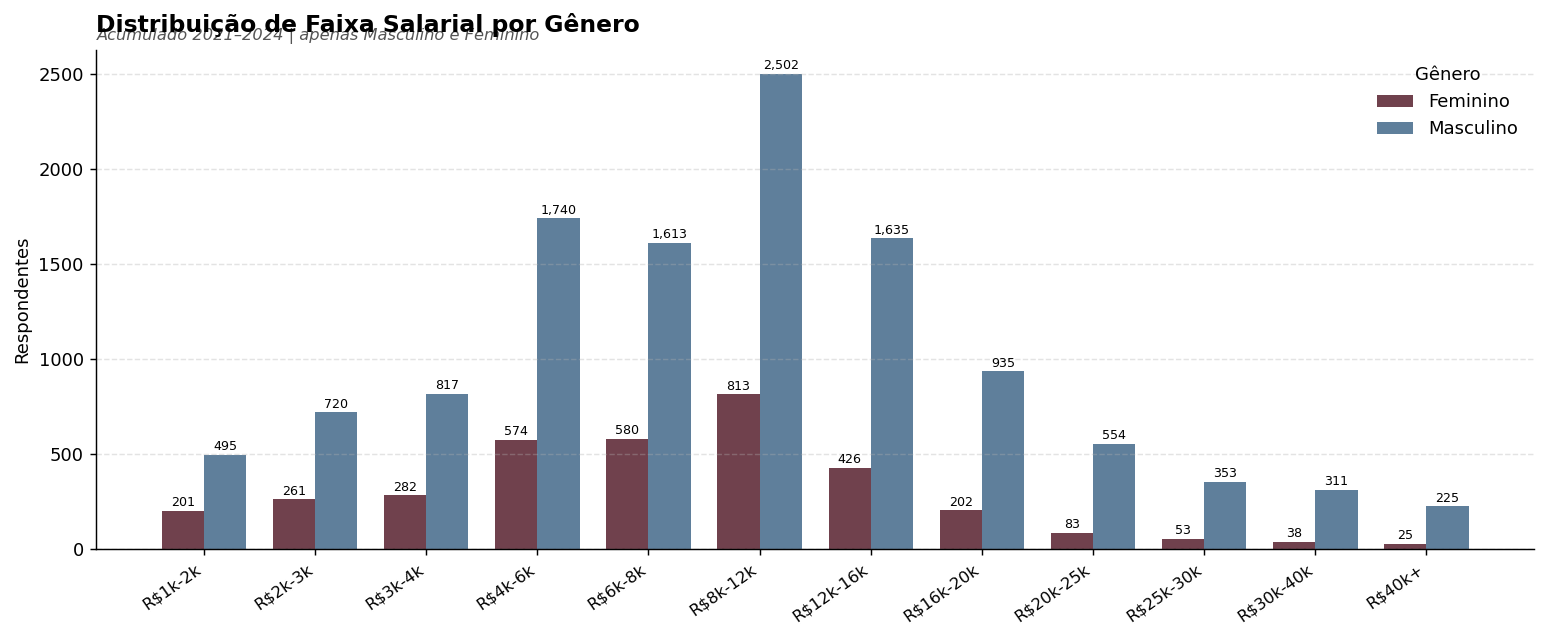

In [3]:
# Agrupa por faixa salarial + gênero somando todos os anos
sal = (
    df.groupby(['faixa_salarial', 'genero'], observed=True)
    .size()
    .reset_index(name='n')
)

# Pivota para barras lado a lado
sal_pivot = sal.pivot(index='faixa_salarial', columns='genero', values='n').fillna(0)
sal_pivot = sal_pivot.reindex(FAIXA_SALARIAL_ORDEM)  # mantém ordem

fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(sal_pivot))
w = 0.38
for i, genero in enumerate(['Feminino', 'Masculino']):
    offset = (i - 0.5) * w
    bars = ax.bar(x + offset, sal_pivot[genero], width=w,
                  color=CORES[genero], label=genero, alpha=0.92)
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 8,
                    f'{int(h):,}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(sal_pivot.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Respondentes', fontsize=10)
ax.legend(title='Gênero', frameon=False)
titulo_e_fonte(ax, 'Distribuição de Faixa Salarial por Gênero',
               'Acumulado 2021–2024 | apenas Masculino e Feminino')
plt.tight_layout()
plt.savefig('g1_faixa_salarial_genero.png', bbox_inches='tight')
plt.show()

---
## Gráfico 2 — Proporção de Senioridade × Gênero por Ano

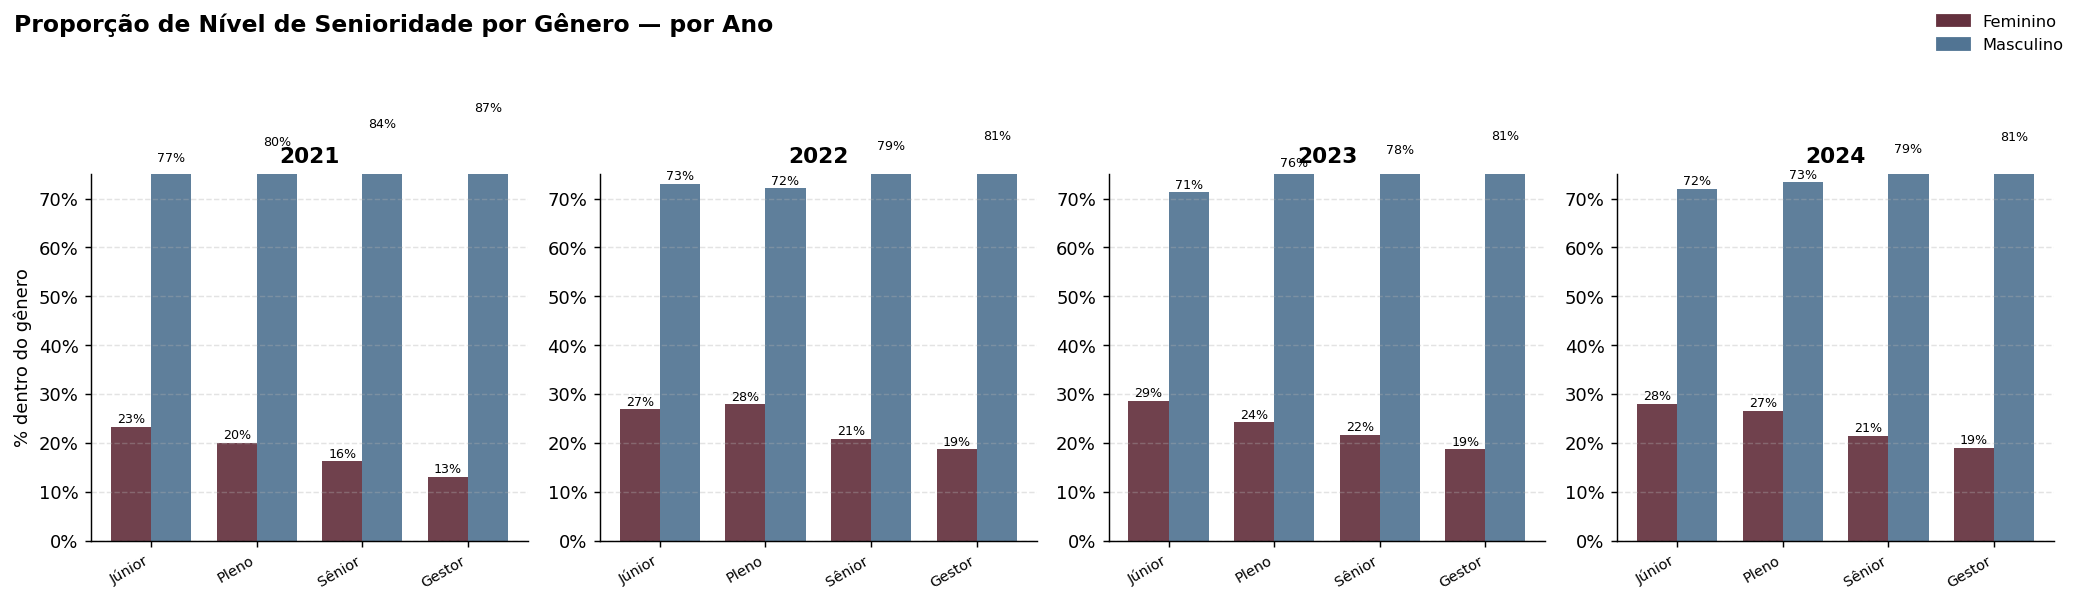

In [4]:
props_nivel = prop_por_ano_grupo(df.dropna(subset=['nivel']), 'nivel')

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), sharey=False)

for ax, ano in zip(axes, ANOS):
    prop = props_nivel[ano]
    bottom_f = np.zeros(len(prop))
    bottom_m = np.zeros(len(prop))

    x = np.arange(len(prop))
    w = 0.38

    for i, genero in enumerate(['Feminino', 'Masculino']):
        vals = prop[genero].values if genero in prop.columns else np.zeros(len(prop))
        offset = (i - 0.5) * w
        ax.bar(x + offset, vals, width=w, color=CORES[genero], alpha=0.92, label=genero)
        for j, v in enumerate(vals):
            if v >= 3:
                ax.text(x[j] + offset, v + 0.8, f'{v:.0f}%',
                        ha='center', fontsize=7)

    ax.set_title(ano, fontweight='bold', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(prop.index, rotation=30, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_ylim(0, 75)
    ax.set_ylabel('% dentro do gênero' if ano == '2021' else '')

fig.legend(handles=LEGENDA_GENERO, loc='upper right', frameon=False, fontsize=9)
fig.suptitle('Proporção de Nível de Senioridade por Gênero — por Ano',
             fontsize=13, fontweight='bold', x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.savefig('g2_senioridade_genero_ano.png', bbox_inches='tight')
plt.show()

---
## Gráfico 3 — Distribuição de Escolaridade × Gênero

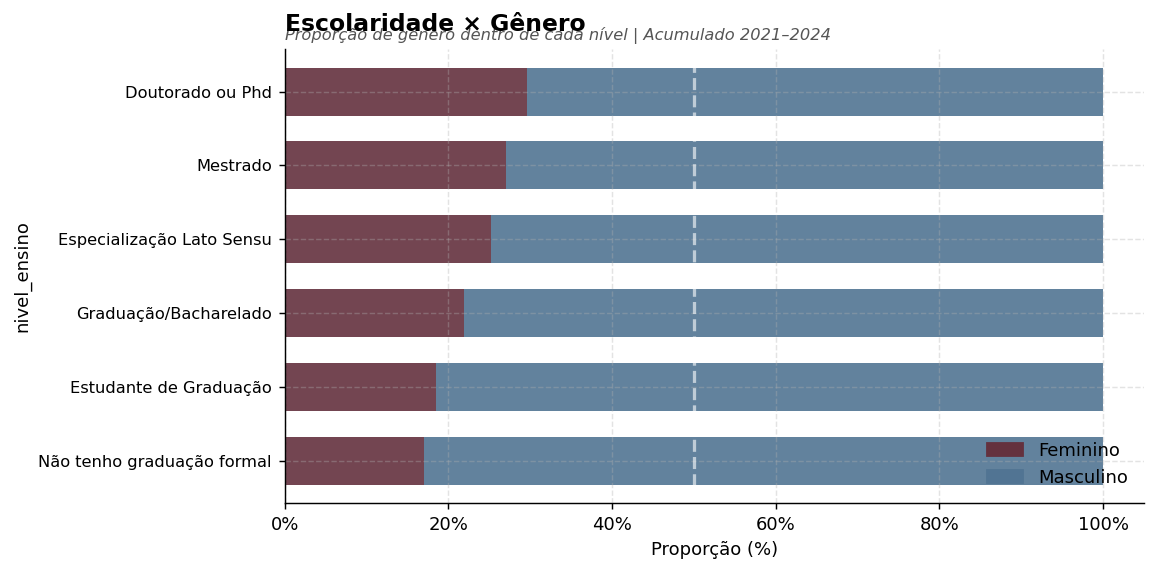

In [5]:
# Proporção de gênero dentro de cada nível de escolaridade (todos os anos)
escol = prop_por_grupo(df.dropna(subset=['nivel_ensino']), 'nivel_ensino')

fig, ax = plt.subplots(figsize=(9, 4.5))

escol[['Feminino', 'Masculino']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[CORES['Feminino'], CORES['Masculino']],
    alpha=0.9, width=0.65
)
ax.axvline(50, color='white', linewidth=1.8, linestyle='--', alpha=0.6)
add_value_labels(ax, threshold=4)

ax.set_xlabel('Proporção (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_yticklabels(escol.index, fontsize=9)
ax.legend(handles=LEGENDA_GENERO, frameon=False, loc='lower right')
titulo_e_fonte(ax, 'Escolaridade × Gênero',
               'Proporção de gênero dentro de cada nível | Acumulado 2021–2024')
plt.tight_layout()
plt.savefig('g3_escolaridade_genero.png', bbox_inches='tight')
plt.show()

---
## Gráfico 4 — Área de Formação × Gênero

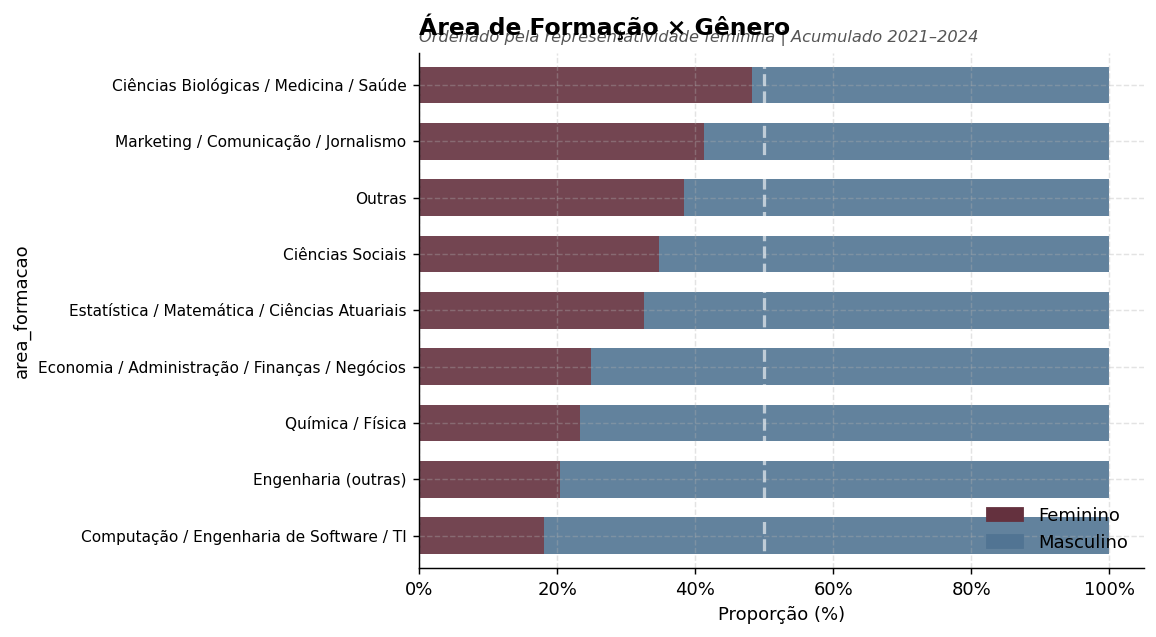

In [6]:
area = prop_por_grupo(df.dropna(subset=['area_formacao']), 'area_formacao')

# Ordena pelo percentual feminino (mais representadas primeiro)
area = area.sort_values('Feminino', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

area[['Feminino', 'Masculino']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[CORES['Feminino'], CORES['Masculino']],
    alpha=0.9, width=0.65
)
ax.axvline(50, color='white', linewidth=1.8, linestyle='--', alpha=0.6)
add_value_labels(ax, threshold=4)

ax.set_xlabel('Proporção (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_yticklabels(area.index, fontsize=8.5)
ax.legend(handles=LEGENDA_GENERO, frameon=False, loc='lower right')
titulo_e_fonte(ax, 'Área de Formação × Gênero',
               'Ordenado pela representatividade feminina | Acumulado 2021–2024')
plt.tight_layout()
plt.savefig('g4_area_formacao_genero.png', bbox_inches='tight')
plt.show()

---
## Gráfico 5 — Evolução da Escolaridade × Gênero por Ano
> *Diferente do Gráfico 3 (acumulado): aqui vemos a evolução ano a ano.*

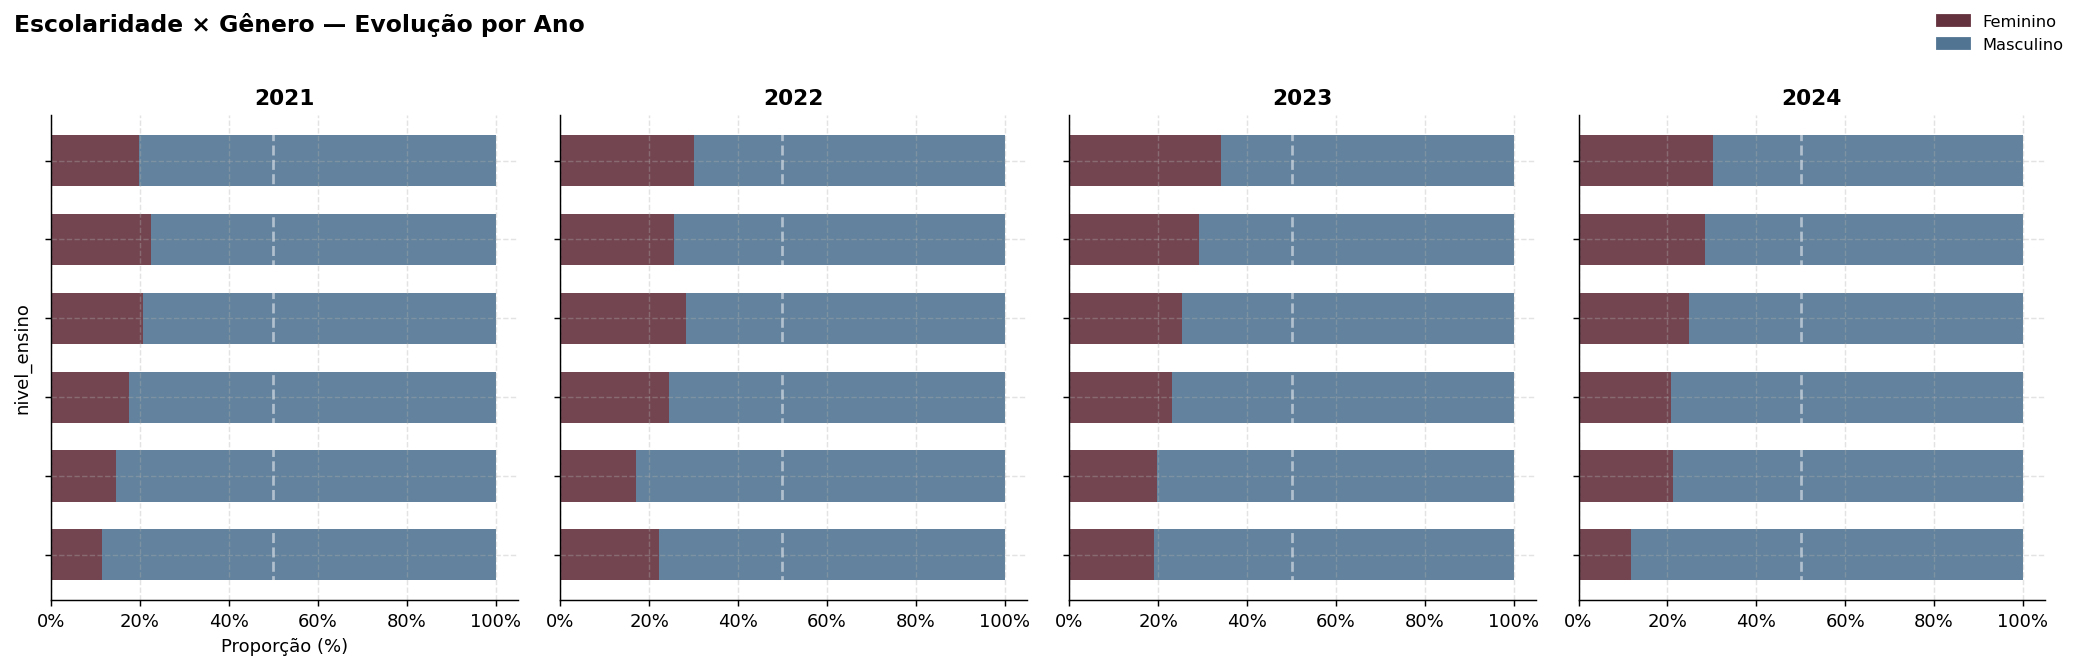

In [7]:
props_escol = prop_por_ano_grupo(df.dropna(subset=['nivel_ensino']), 'nivel_ensino')

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)

for ax, ano in zip(axes, ANOS):
    prop = props_escol[ano]
    prop[['Feminino', 'Masculino']].plot(
        kind='barh', stacked=True, ax=ax,
        color=[CORES['Feminino'], CORES['Masculino']],
        alpha=0.9, width=0.65, legend=False
    )
    ax.axvline(50, color='white', linewidth=1.5, linestyle='--', alpha=0.5)
    ax.set_title(ano, fontweight='bold', fontsize=12)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xlabel('Proporção (%)' if ano == '2021' else '')
    if ano != '2021':
        ax.set_yticklabels([])

fig.legend(handles=LEGENDA_GENERO, loc='upper right', frameon=False, fontsize=9)
fig.suptitle('Escolaridade × Gênero — Evolução por Ano',
             fontsize=13, fontweight='bold', x=0.01, ha='left', y=1.02)
plt.tight_layout()
plt.savefig('g5_escolaridade_genero_ano.png', bbox_inches='tight')
plt.show()

---
## Gráfico 6 — Cargo × Gênero

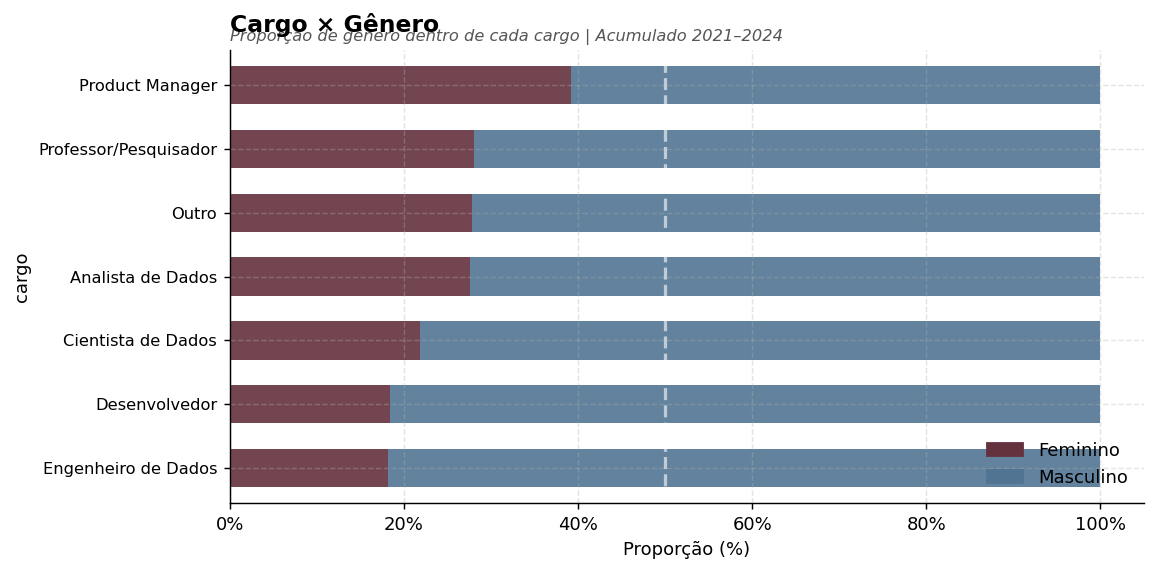

In [8]:
cargo = prop_por_grupo(df.dropna(subset=['cargo']), 'cargo')
cargo = cargo.sort_values('Feminino', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4.5))

cargo[['Feminino', 'Masculino']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[CORES['Feminino'], CORES['Masculino']],
    alpha=0.9, width=0.6
)
ax.axvline(50, color='white', linewidth=1.8, linestyle='--', alpha=0.6)
add_value_labels(ax, threshold=3)

ax.set_xlabel('Proporção (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_yticklabels(cargo.index, fontsize=9)
ax.legend(handles=LEGENDA_GENERO, frameon=False, loc='lower right')
titulo_e_fonte(ax, 'Cargo × Gênero',
               'Proporção de gênero dentro de cada cargo | Acumulado 2021–2024')
plt.tight_layout()
plt.savefig('g6_cargo_genero.png', bbox_inches='tight')
plt.show()

---
## Gráfico 7 — Modalidade de Trabalho × Gênero

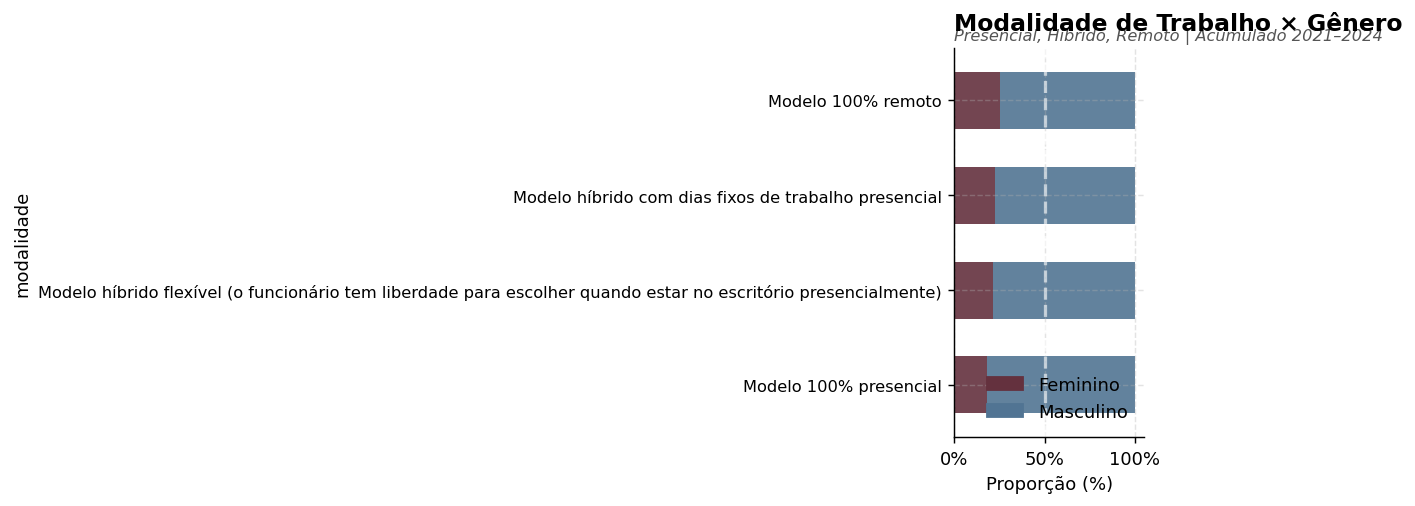

In [9]:
modal = prop_por_grupo(df.dropna(subset=['modalidade']), 'modalidade')
modal = modal.sort_values('Feminino', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))

modal[['Feminino', 'Masculino']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[CORES['Feminino'], CORES['Masculino']],
    alpha=0.9, width=0.6
)
ax.axvline(50, color='white', linewidth=1.8, linestyle='--', alpha=0.6)
add_value_labels(ax, threshold=3)

ax.set_xlabel('Proporção (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_yticklabels(modal.index, fontsize=9)
ax.legend(handles=LEGENDA_GENERO, frameon=False, loc='lower right')
titulo_e_fonte(ax, 'Modalidade de Trabalho × Gênero',
               'Presencial, Híbrido, Remoto | Acumulado 2021–2024')
plt.tight_layout()
plt.savefig('g7_modalidade_genero.png', bbox_inches='tight')
plt.show()

---
## Gráfico 8 — Situação de Trabalho × Gênero

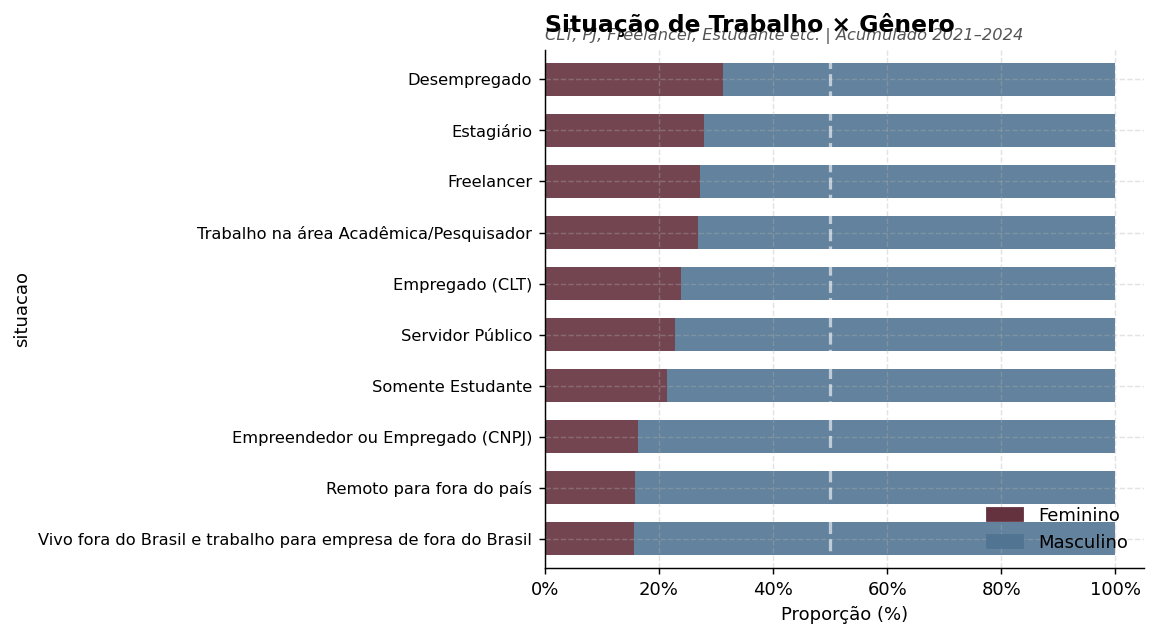

In [10]:
situ = prop_por_grupo(df.dropna(subset=['situacao']), 'situacao')
situ = situ.sort_values('Feminino', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

situ[['Feminino', 'Masculino']].plot(
    kind='barh', stacked=True, ax=ax,
    color=[CORES['Feminino'], CORES['Masculino']],
    alpha=0.9, width=0.65
)
ax.axvline(50, color='white', linewidth=1.8, linestyle='--', alpha=0.6)
add_value_labels(ax, threshold=3)

ax.set_xlabel('Proporção (%)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_yticklabels(situ.index, fontsize=9)
ax.legend(handles=LEGENDA_GENERO, frameon=False, loc='lower right')
titulo_e_fonte(ax, 'Situação de Trabalho × Gênero',
               'CLT, PJ, Freelancer, Estudante etc. | Acumulado 2021–2024')
plt.tight_layout()
plt.savefig('g8_situacao_genero.png', bbox_inches='tight')
plt.show()

---
## Bônus — Painel resumo: proporção feminina ao longo dos anos
> Evolução do percentual de mulheres no mercado de dados, por ano.

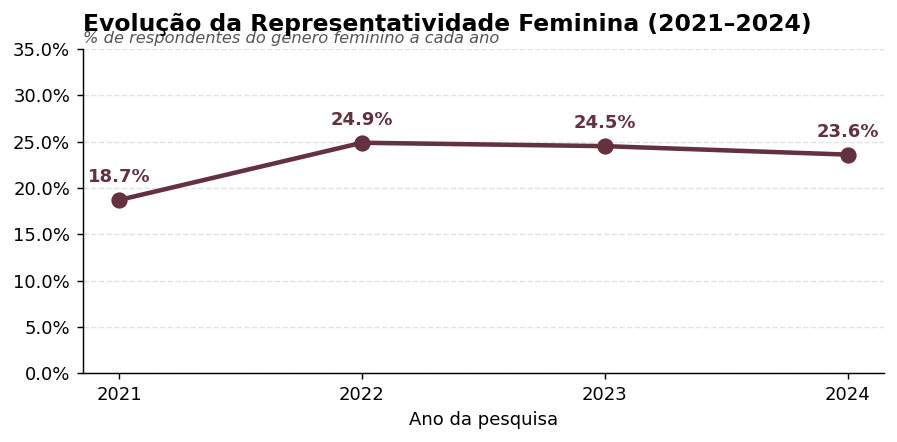

In [11]:
evolucao = (
    df.groupby(['ano_pesquisa', 'genero'])
    .size()
    .unstack(fill_value=0)
    .assign(pct_feminino=lambda x: x['Feminino'] / (x['Feminino'] + x['Masculino']) * 100)
)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(ANOS, evolucao.loc[ANOS, 'pct_feminino'],
        marker='o', linewidth=2.5, color=CORES['Feminino'], markersize=8)

for ano, val in zip(ANOS, evolucao.loc[ANOS, 'pct_feminino']):
    ax.annotate(f'{val:.1f}%', (ano, val),
                textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold', color=CORES['Feminino'])

ax.set_ylim(0, 35)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Ano da pesquisa')
titulo_e_fonte(ax, 'Evolução da Representatividade Feminina (2021–2024)',
               '% de respondentes do gênero feminino a cada ano')
plt.tight_layout()
plt.savefig('g_bonus_evolucao_feminino.png', bbox_inches='tight')
plt.show()